# Pipeline ML - Audit qualité des données

Utilisation de *kagglehub* pour télécherger la donnée

In [ ]:
# !pip install kagglehub

In [2]:
from pathlib import Path
import pandas as pd
import kagglehub

# Création du dossier data
Path("data").mkdir(exist_ok=True)

# Téléchargement du dataset
path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)

print("Dataset téléchargé dans :", path)

c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 172k/172k [00:00<00:00, 730kB/s]

Extracting files...
Dataset téléchargé dans : C:\Users\abedja\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


Le dataset est téléchargé automatiquement via kagglehub puis copié dans le dossier `data/`.

In [3]:
from pathlib import Path
import shutil

source = Path(path) / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
destination = Path("data") / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

shutil.copy(source, destination)

print("CSV copié dans :", destination)

CSV copié dans : data\WA_Fn-UseC_-Telco-Customer-Churn.csv


## Phase 1 - Audit

In [13]:
def audit_qualite(df):
    """
    Affiche un rapport de santé du dataset :
    - forme
    - types
    - % de valeurs manquantes
    - répartition de la cible Churn
    """

    print(f"\nForme : {df.shape}")

    print("\nTypes :")
    print(df.dtypes.value_counts())

    manquants = (
        df.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    manquants_visibles = manquants[manquants > 0]

    print("\nPourcentage de valeurs manquantes :")

    if len(manquants_visibles) == 0:
        print("Aucune valeur manquante détectée")
    else:
        print(manquants_visibles)

    if "Churn" in df.columns:

        repartition = df["Churn"].value_counts()

        pourcentage = (
            df["Churn"]
            .value_counts(normalize=True)
            * 100
        )

        print("\nRépartition Churn :")

        for valeur in repartition.index:

            print(
                f"{valeur} : "
                f"{repartition[valeur]} "
                f"({pourcentage[valeur]:.2f}%)"
            )

In [14]:
df = pd.read_csv(
    "data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()
audit_qualite(df)


Forme : (7043, 21)

Types :
str        18
int64       2
float64     1
Name: count, dtype: int64

Pourcentage de valeurs manquantes :
Aucune valeur manquante détectée

Répartition Churn :
No : 5174 (73.46%)
Yes : 1869 (26.54%)


### Cas limite
Dataset contenant uniquement les churners

In [16]:
df_yes = df[df["Churn"] == "Yes"]

audit_qualite(df_yes)


Forme : (1869, 21)

Types :
str        18
int64       2
float64     1
Name: count, dtype: int64

Pourcentage de valeurs manquantes :
Aucune valeur manquante détectée

Répartition Churn :
Yes : 1869 (100.00%)


In [17]:
df_no = df[df["Churn"] == "No"]

audit_qualite(df_no)


Forme : (5174, 21)

Types :
str        18
int64       2
float64     1
Name: count, dtype: int64

Pourcentage de valeurs manquantes :
Aucune valeur manquante détectée

Répartition Churn :
No : 5174 (100.00%)


### Cas adversarial

Ici le but est de montrer que l'audit rend visible le déséquilibre.

In [18]:
repartition = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

print(repartition)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


##### Observation

Le dataset est déséquilibré :

- Non churn : 73.46 %
- Churn : 26.54 %

Un modèle qui prédirait toujours "No" obtiendrait déjà
73 % d'accuracy sans apprendre quoi que ce soit.

L'accuracy seule ne sera donc pas suffisante pour évaluer
les modèles lors des prochaines étapes.

## Phase 2

In [19]:
print("Type actuel :", df["TotalCharges"].dtype)

df["TotalCharges"].head()

Type actuel : str


0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

In [20]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [21]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [22]:
def reparer_total_charges(df):
    """
    Convertit TotalCharges en numérique
    et traite les trous cachés.
    """

    df = df.copy()

    print("Type avant :", df["TotalCharges"].dtype)

    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    nb_nan = df["TotalCharges"].isna().sum()

    print(f"Trous cachés révélés : {nb_nan}")

    mediane = df["TotalCharges"].median()

    df["TotalCharges"] = (
        df["TotalCharges"]
        .fillna(mediane)
    )

    print(
        f"Médiane utilisée : {mediane:.2f}"
    )

    print(
        "Type après :",
        df["TotalCharges"].dtype
    )

    print(
        "NaN restants :",
        df["TotalCharges"].isna().sum()
    )

    return df

In [23]:
df = reparer_total_charges(df)

Type avant : str
Trous cachés révélés : 11
Médiane utilisée : 1397.47
Type après : float64
NaN restants : 0


In [24]:
df["TotalCharges"].describe()

count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [25]:
df["TotalCharges"].dtype

dtype('float64')

In [26]:
test = pd.Series(
    ["abc", "def", "ghi"]
)

conversion = pd.to_numeric(
    test,
    errors="coerce"
)

print(conversion.isna().mean())

1.0


In [27]:
pd.to_numeric(
    pd.Series(["29,90"]),
    errors="coerce"
)

0   NaN
dtype: float64

In [28]:
df["TotalCharges"].astype(str).str.contains(",").sum()

np.int64(0)

### Phase 3

Passer de : 7043 lignes × 21 colonnes
à un dataset : 100 % numérique

sans perdre d'information utile.

1. Examiner les colonnes catégorielles

Avant de modifier quoi que ce soit :

In [30]:
colonnes_objet = df.select_dtypes(include="object").columns

print(f"Nombre de colonnes catégorielles : {len(colonnes_objet)}")
print(colonnes_objet.tolist())

Nombre de colonnes catégorielles : 17
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\abedja\AppData\Local\Temp\ipykernel_16196\387828837.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_objet = df.select_dtypes(include="object").columns


2. Supprimer customerID

Un identifiant n'est pas une feature.

In [31]:
df = df.drop(columns=["customerID"])

print("customerID supprimée")

customerID supprimée


3. Vérifier les modalités

In [32]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].unique())


gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract
<StringArray>
['Month-to-month', 'One year', '

C:\Users\abedja\AppData\Local\Temp\ipykernel_16196\88652429.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


4. Fonction d'encodage

In [33]:
def encoder_features(df):

    df = df.copy()

    print("Dimensions avant :", df.shape)

    # Encodage One-Hot
    df = pd.get_dummies(
        df,
        drop_first=True,
        dtype=int
    )

    print("Dimensions après :", df.shape)

    return df

In [34]:
df_encoded = encoder_features(df)

Dimensions avant : (7043, 20)
Dimensions après : (7043, 31)


5. Vérifications demandées

#### Vérification 1

Plus aucune colonne texte :

In [35]:
df_encoded.select_dtypes(include="object").columns

Index([], dtype='str')

#### Vérification 2
Toutes les colonnes sont numériques :

In [36]:
df_encoded.dtypes.value_counts()

int64      29
float64     2
Name: count, dtype: int64

#### Vérification 3

Dimensions finales :

In [37]:
print(df_encoded.shape)

(7043, 31)


In [39]:
df_customer = pd.read_csv(
    "data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print(
    df_customer["customerID"].nunique()
)

7043


In [40]:
print(
    pd.get_dummies(
        df_customer["customerID"]
    ).shape
)

(7043, 7043)


### Phase 4 

Détection des valeurs aberrantes

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

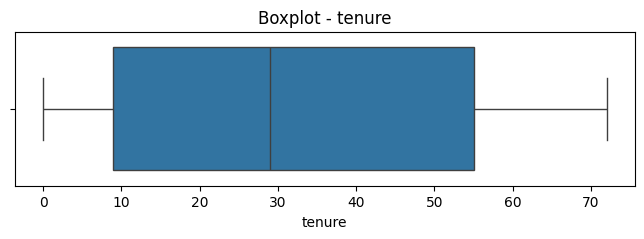

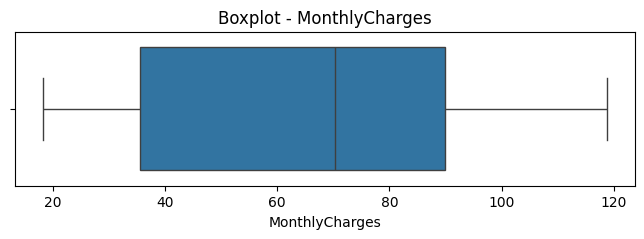

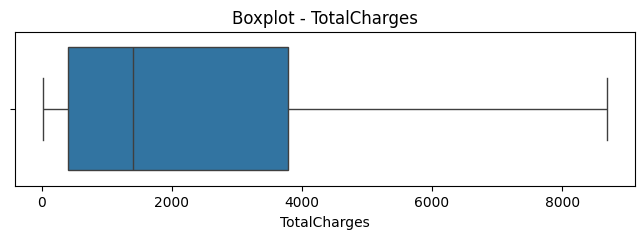

In [42]:
colonnes_numeriques = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for col in colonnes_numeriques:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot - {col}")

    plt.show()

In [43]:
def detecter_outliers_iqr(df, colonne):
    """
    Renvoie :
    borne_basse,
    borne_haute,
    nombre_outliers
    """

    Q1 = df[colonne].quantile(0.25)

    Q3 = df[colonne].quantile(0.75)

    IQR = Q3 - Q1

    borne_basse = Q1 - 1.5 * IQR

    borne_haute = Q3 + 1.5 * IQR

    masque_outliers = (
        (df[colonne] < borne_basse)
        |
        (df[colonne] > borne_haute)
    )

    nb_outliers = masque_outliers.sum()

    return (
        borne_basse,
        borne_haute,
        nb_outliers
    )

In [44]:
for col in [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]:

    borne_basse, borne_haute, nb_outliers = (
        detecter_outliers_iqr(
            df,
            col
        )
    )

    print(f"\n{col}")

    print(
        f"Borne basse : {borne_basse:.2f}"
    )

    print(
        f"Borne haute : {borne_haute:.2f}"
    )

    print(
        f"Nombre d'outliers : {nb_outliers}"
    )


tenure
Borne basse : -60.00
Borne haute : 124.00
Nombre d'outliers : 0

MonthlyCharges
Borne basse : -46.02
Borne haute : 171.38
Nombre d'outliers : 0

TotalCharges
Borne basse : -4674.34
Borne haute : 8863.16
Nombre d'outliers : 0


#### Cas limite

In [45]:
test_df = pd.DataFrame({
    "x": [10,11,12,13,14,15]
})

detecter_outliers_iqr(
    test_df,
    "x"
)

(np.float64(7.5), np.float64(17.5), np.int64(0))

#### Cas adversarial

In [46]:
borne_basse, borne_haute, _ = (
    detecter_outliers_iqr(
        df,
        "MonthlyCharges"
    )
)

outliers = df[
    (df["MonthlyCharges"] < borne_basse)
    |
    (df["MonthlyCharges"] > borne_haute)
]

print(
    outliers["Churn"]
    .value_counts()
)

Series([], Name: count, dtype: int64)
